## 1. Loading and Preprocessing

In [1]:
# Load the Diabetes dataset
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



Target (y) head:


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


The first 5 rows of the features (`X`) and target (`y`) are displayed, showing the initial structure of the dataset. We do this to inspect the raw data and understand its format and the nature of the features (numerical) and the target (continuous disease progression score).

In [2]:
# Handle any missing values if present
# The Diabetes dataset from sklearn is usually clean, but we'll check.
print("Missing values in features (X):\n", X.isnull().sum())
print("\nMissing values in target (y):\n", y.isnull().sum())

print("\nNo missing values found in the Diabetes dataset.")

Missing values in features (X):
 age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Missing values in target (y):
 0

No missing values found in the Diabetes dataset.


The output confirms that there are no missing values in either the features (`X`) or the target (`y`). This is a crucial step to ensure data quality, as missing values can lead to errors or biased model training. Finding no missing values means the dataset is clean and ready for further processing without imputation.

In [3]:
# Normalize the features to ensure better performance of the ANN model.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Normalized Features (X_scaled_df) head:")
display(X_scaled_df.head())

print("\nMean of scaled features (should be close to 0):\n", X_scaled_df.mean())
print("\nStandard deviation of scaled features (should be close to 1):\n", X_scaled_df.std())

Normalized Features (X_scaled_df) head:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.800500,1.065488,1.297088,0.459841,-0.929746,-0.732065,-0.912451,-0.054499,0.418531,-0.370989
1,-0.039567,-0.938537,-1.082180,-0.553505,-0.177624,-0.402886,1.564414,-0.830301,-1.436589,-1.938479
2,1.793307,1.065488,0.934533,-0.119214,-0.958674,-0.718897,-0.680245,-0.054499,0.060156,-0.545154
3,-1.872441,-0.938537,-0.243771,-0.770650,0.256292,0.525397,-0.757647,0.721302,0.476983,-0.196823
4,0.113172,-0.938537,-0.764944,0.459841,0.082726,0.327890,0.171178,-0.054499,-0.672502,-0.980568



Mean of scaled features (should be close to 0):
 age   -8.037814e-18
sex    1.220743e-16
bmi    6.530724e-18
bp    -1.145388e-16
s1     5.525997e-18
s2    -6.530724e-18
s3    -1.105199e-17
s4     1.273491e-16
s5     8.602973e-18
s6    -7.205774e-17
dtype: float64

Standard deviation of scaled features (should be close to 1):
 age    1.001133
sex    1.001133
bmi    1.001133
bp     1.001133
s1     1.001133
s2     1.001133
s3     1.001133
s4     1.001133
s5     1.001133
s6     1.001133
dtype: float64


The scaled features are displayed, showing their transformed values. The key finding here is that the mean of each scaled feature is very close to 0, and the standard deviation is very close to 1. This confirms that the `StandardScaler` successfully normalized the data. Standardization is essential for ANN models because it helps them converge faster and prevents features with larger scales from dominating the learning process.

## 2. Exploratory Data Analysis (EDA)

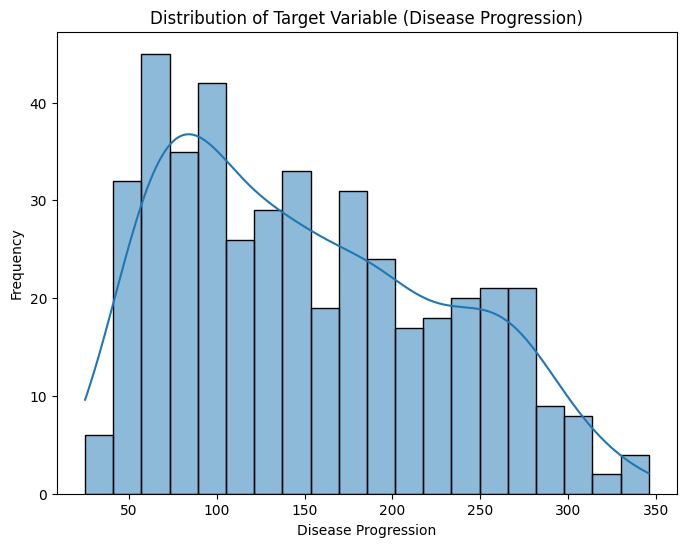

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of the target variable (y)
plt.figure(figsize=(8, 6))
sns.histplot(y, kde=True, bins=20)
plt.title('Distribution of Target Variable (Disease Progression)')
plt.xlabel('Disease Progression')
plt.ylabel('Frequency')
plt.show()

This histogram shows the distribution of the target variable (disease progression). We observe that it appears to be roughly normal but slightly right-skewed, indicating a range of progression levels among individuals. Visualizing the target distribution helps us understand its characteristics and informs potential data transformations or model choices if the distribution were highly irregular.

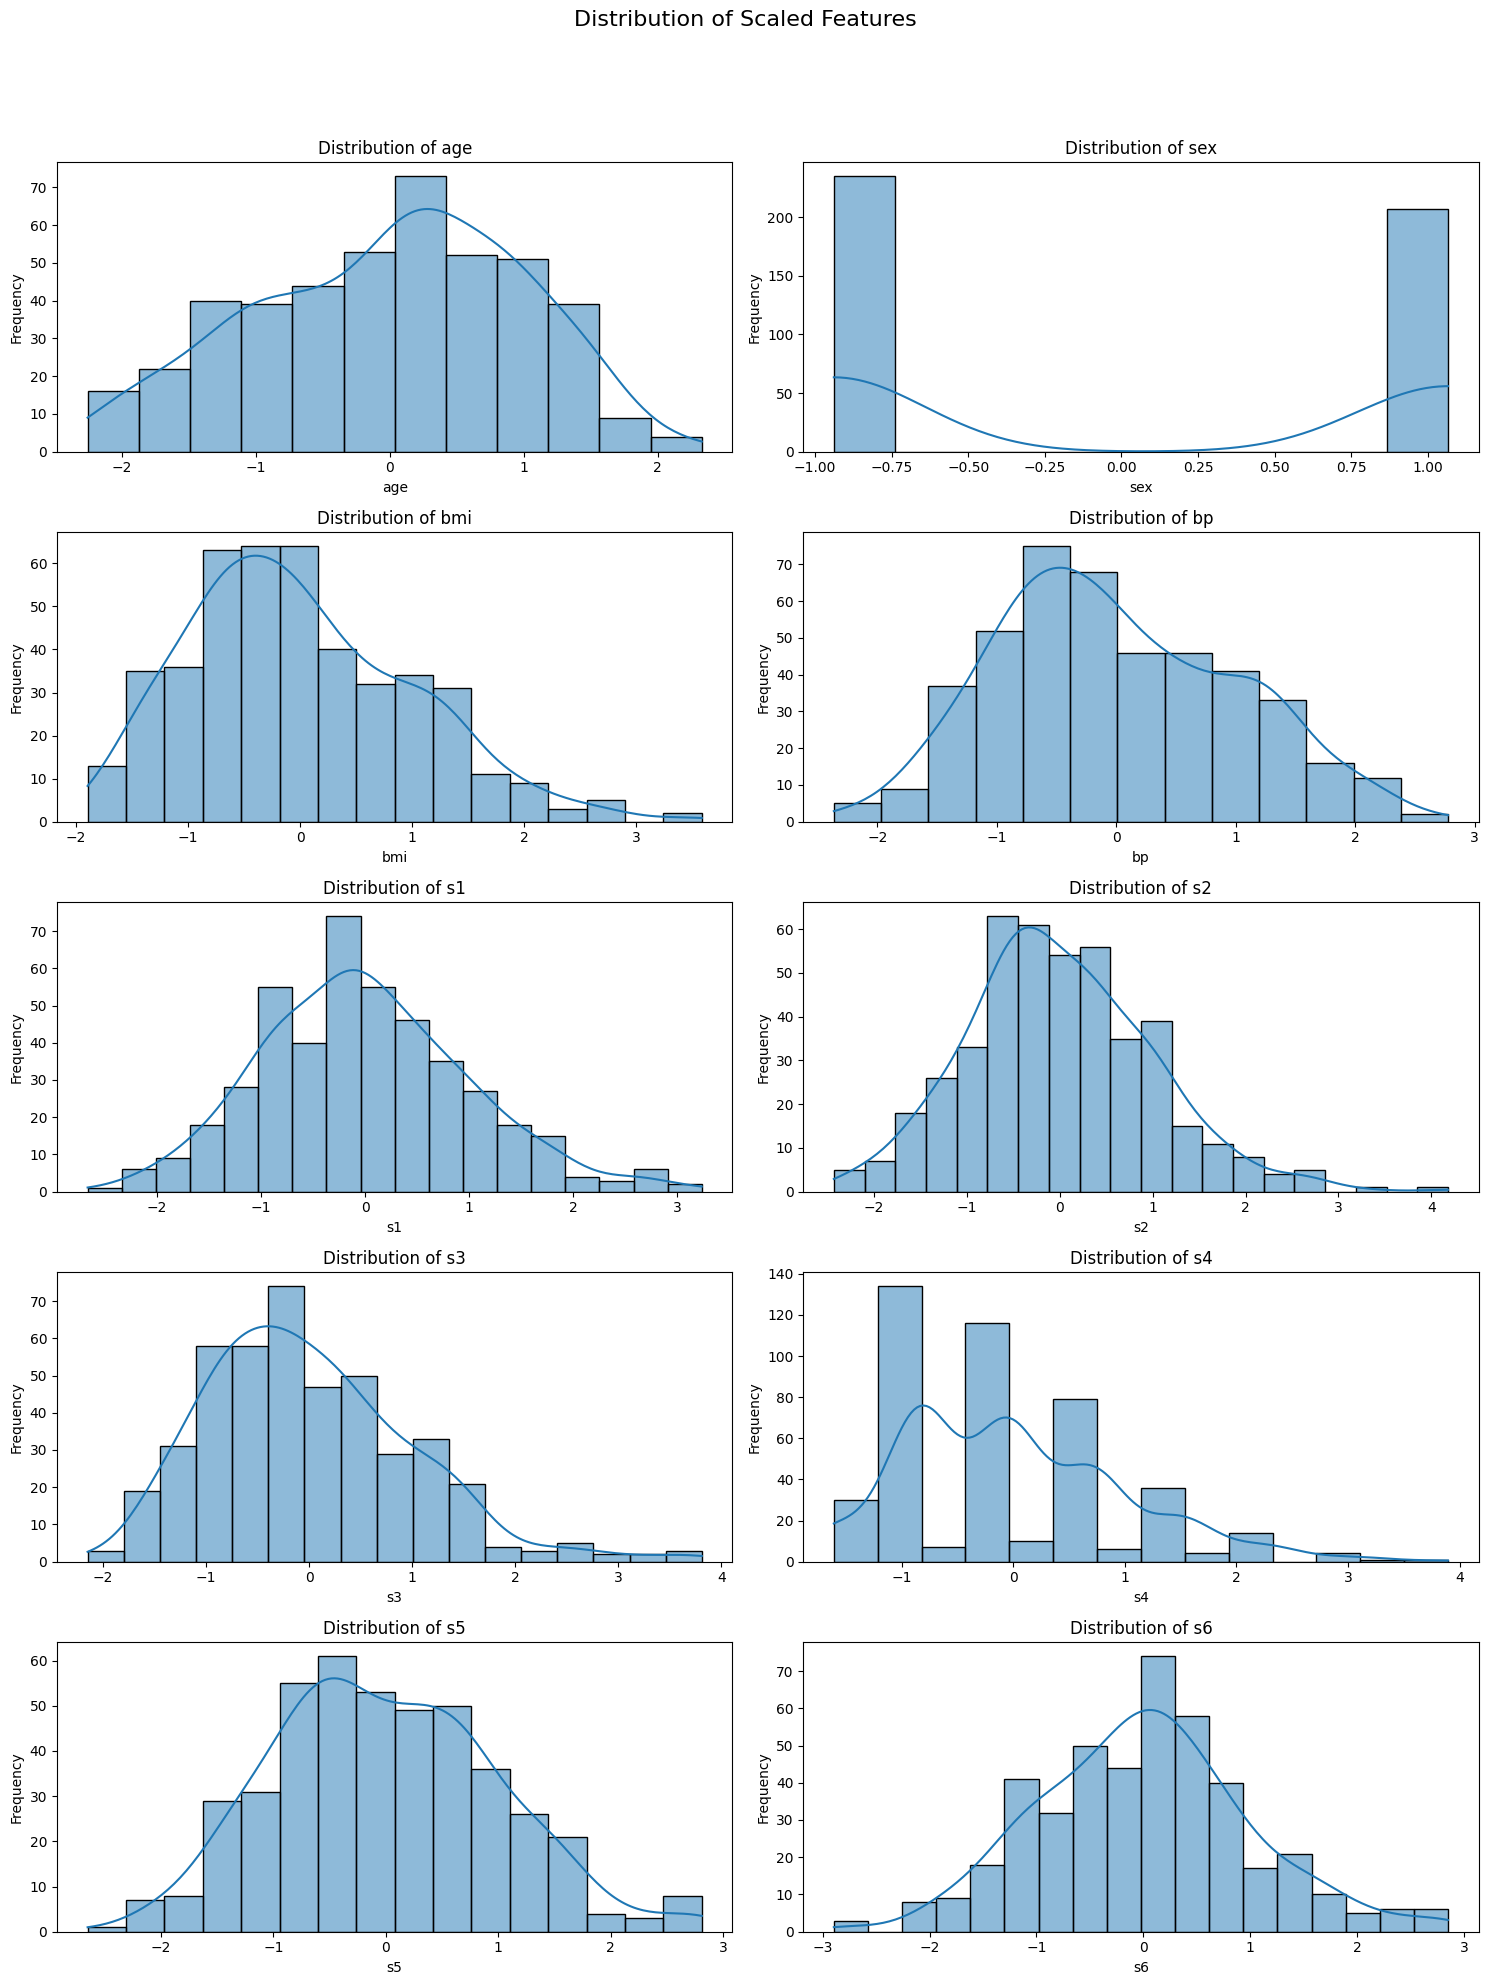

In [5]:
# Distribution of each feature in X_scaled_df

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
fig.suptitle('Distribution of Scaled Features', y=1.02, fontsize=16)
axes = axes.flatten()

for i, column in enumerate(X_scaled_df.columns):
    sns.histplot(X_scaled_df[column], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

These histograms display the distributions of each scaled feature. We found that most features exhibit a somewhat normal distribution around zero, which is the expected outcome after standardization. This visualization confirms the effectiveness of the scaling step and helps identify any features with unusual distributions that might require special handling.

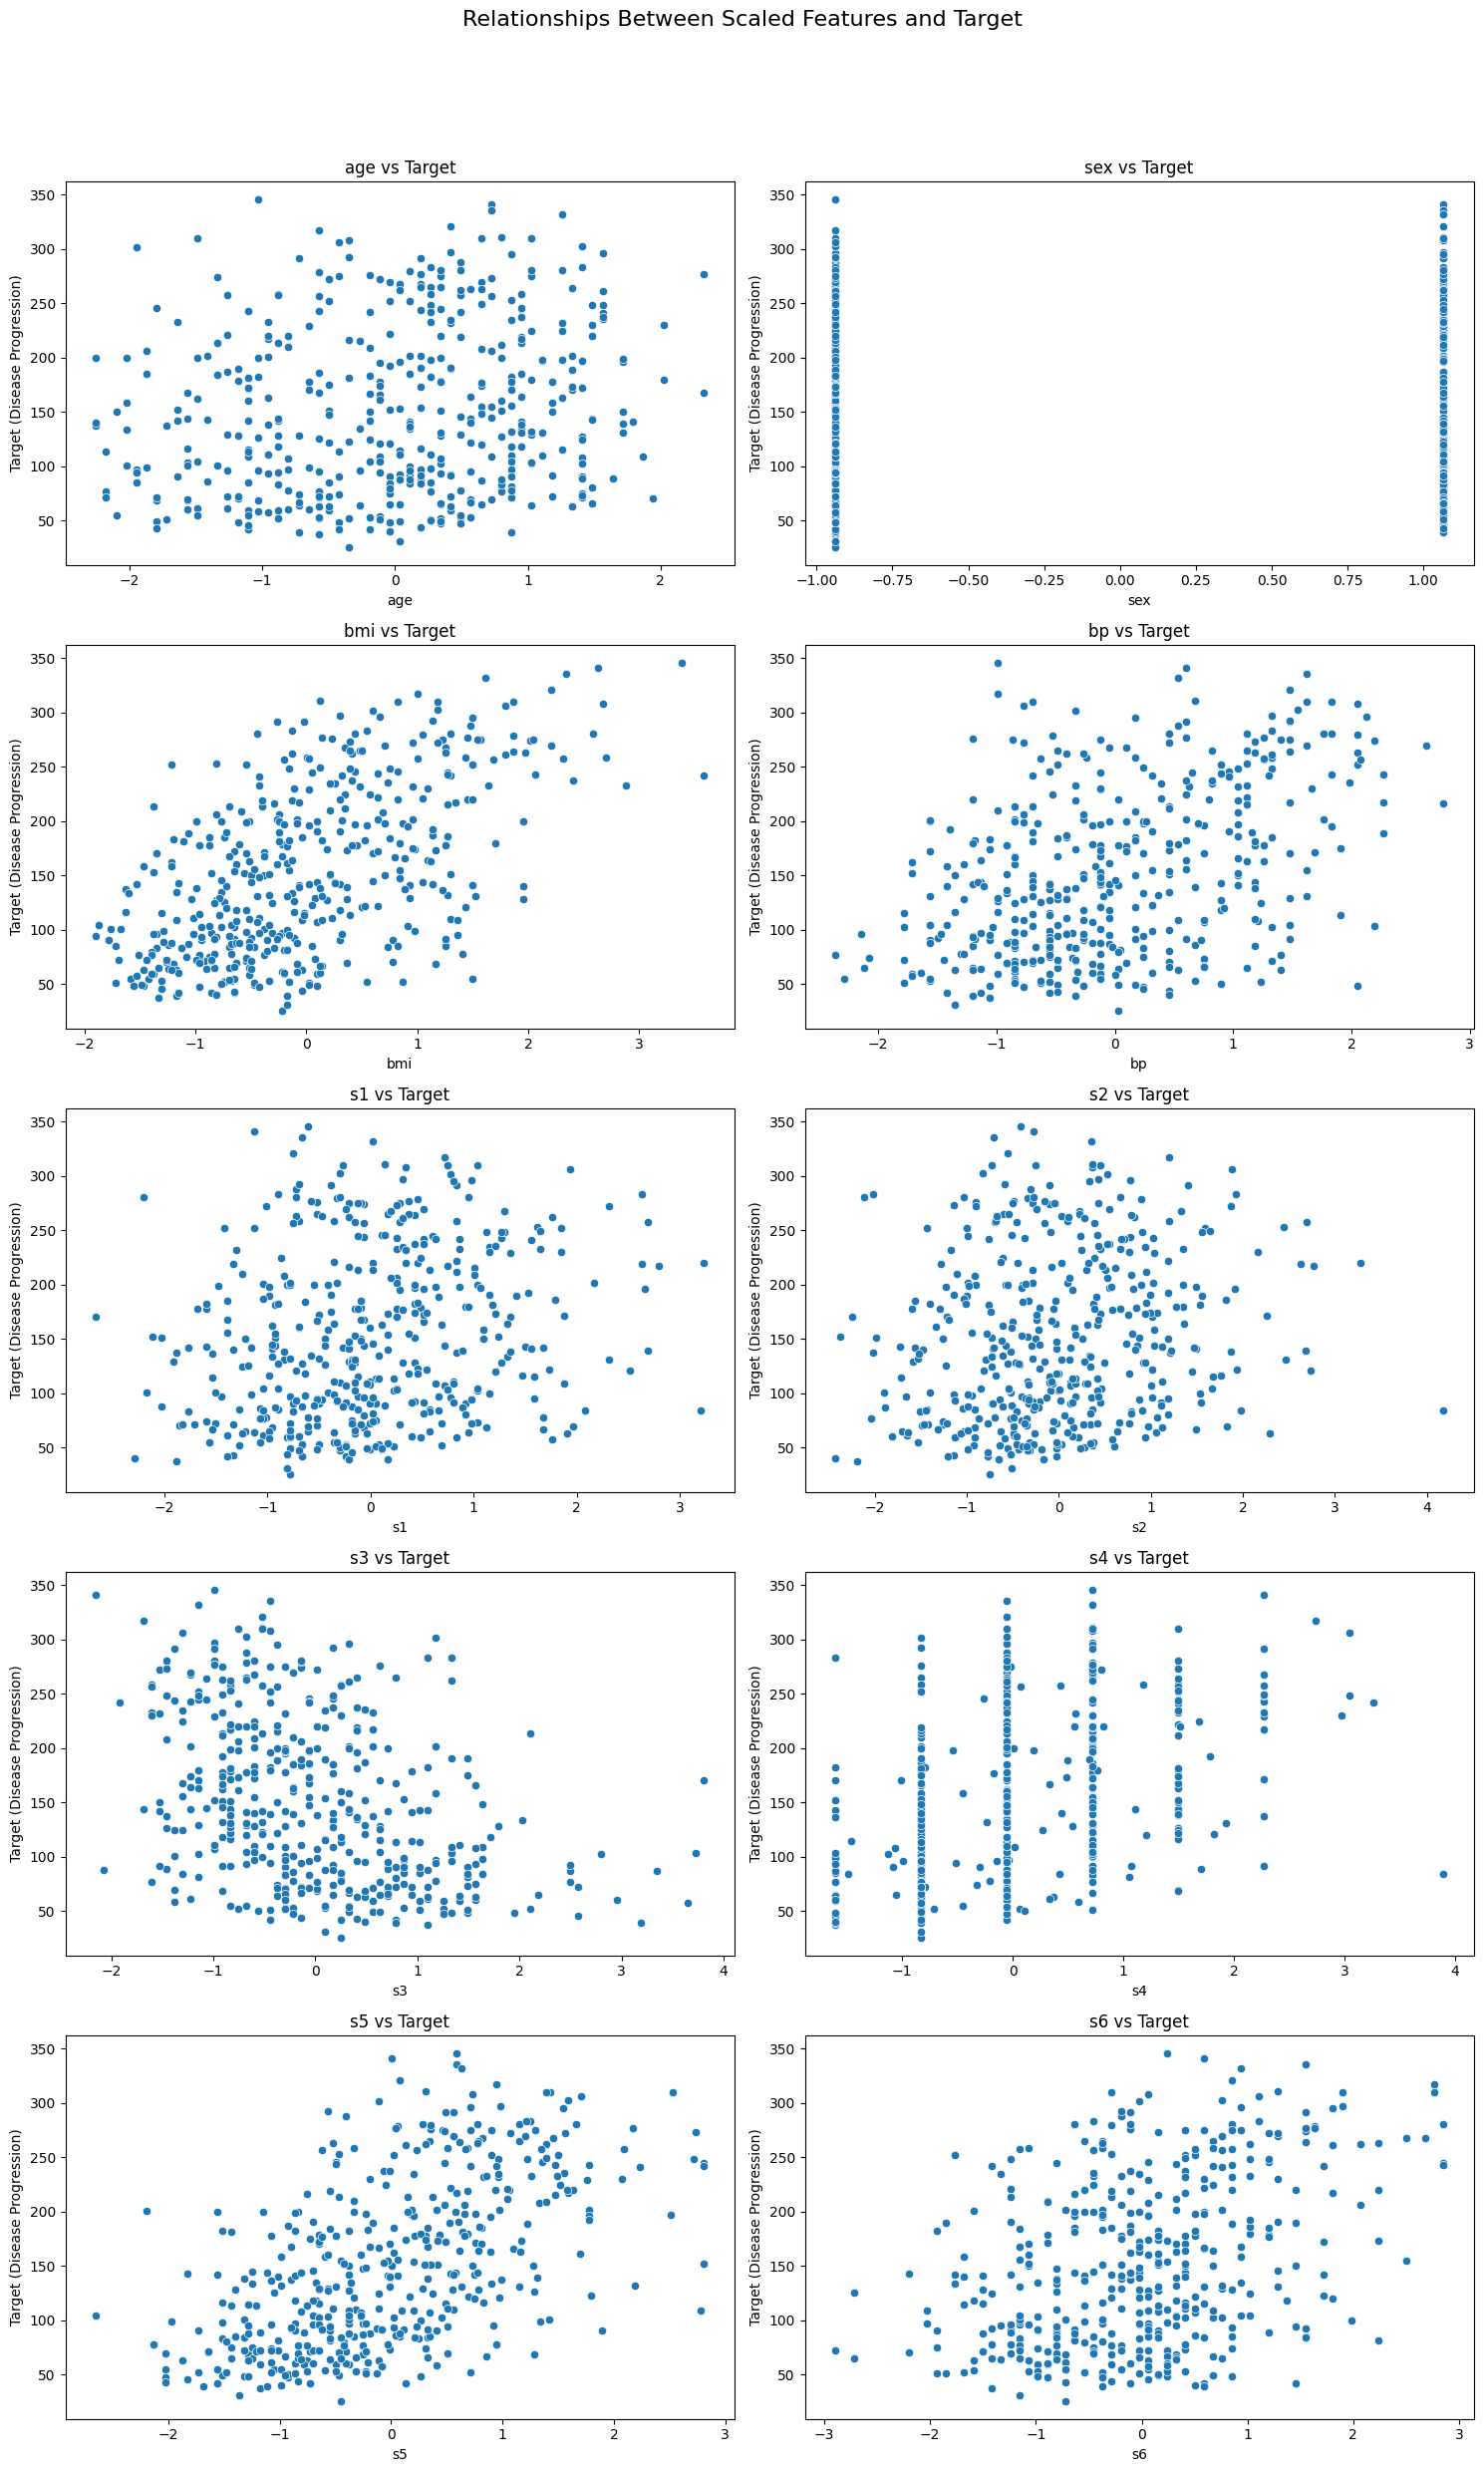

In [6]:
# Relationships between features and the target variable

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 25))
fig.suptitle('Relationships Between Scaled Features and Target', y=1.02, fontsize=16)
axes = axes.flatten()

for i, column in enumerate(X_scaled_df.columns):
    sns.scatterplot(x=X_scaled_df[column], y=y, ax=axes[i])
    axes[i].set_title(f'{column} vs Target')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Target (Disease Progression)')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

These scatter plots illustrate the relationships between each scaled feature and the target variable. We can observe that some features show a clearer linear or non-linear correlation with disease progression than others. This exploratory step is valuable for model understanding, helping us to visually identify which features might be more influential in predicting the target and potentially guiding feature engineering efforts.

## 3. Building the ANN Model

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the ANN architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_scaled_df.shape[1],), name='hidden_layer_1'),
    Dense(32, activation='relu', name='hidden_layer_2'),
    Dense(1, name='output_layer') # Output layer for regression (single continuous value)
])

# Display the model summary
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

None


The model summary provides a detailed overview of the initial Artificial Neural Network (ANN) architecture. We found that it consists of two hidden `Dense` layers with `relu` activation and a single output neuron for regression. This step is crucial for verifying the model's structure, including the number of layers, the number of neurons in each layer, the output shape, and the total number of trainable parameters, ensuring it matches our design intent.

## 4. Training the ANN Model

In [8]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# Using X_scaled_df for features and y for the target variable
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (353, 10)
Testing features shape: (89, 10)
Training target shape: (353,)
Testing target shape: (89,)


The output confirms the successful splitting of the dataset into training and testing sets, showing the number of samples and features in each partition. Specifically, an 80/20 split was performed. This step is fundamental to machine learning to ensure that the model is evaluated on data it has not seen during training, providing an unbiased estimate of its generalization performance.

In [9]:
# Compile the model
# For regression, 'mean_squared_error' is a common loss function.
# 'adam' is a popular and effective optimizer.
model.compile(optimizer='adam', loss='mean_squared_error')

print("Model compiled successfully!")

Model compiled successfully!


This message confirms that the model has been successfully compiled with the Adam optimizer and Mean Squared Error (MSE) loss function. This step is necessary to configure the model for the training process. The choice of `adam` as an optimizer is due to its efficiency and good performance in many scenarios, while `mean_squared_error` is a standard loss function for regression tasks, aiming to minimize the average squared difference between predictions and actual values.

In [10]:
# Train the model on the training data
history = model.fit(
    X_train,
    y_train,
    epochs=100, # Number of training iterations
    batch_size=32, # Number of samples per gradient update
    validation_split=0.2, # Use a portion of the training data for validation
    verbose=1 # Show training progress
)

print("\nModel training complete!")

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 31464.5703 - val_loss: 22334.3066
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31295.3652 - val_loss: 22188.1641
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31109.7402 - val_loss: 22018.5957
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 30888.9688 - val_loss: 21811.4727
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 30608.1914 - val_loss: 21552.8555
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 30248.8945 - val_loss: 21225.0801
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 29792.1953 - val_loss: 20813.6016
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 29189.3965 - val_loss: 20311.9746
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 28462.5449 - val_loss: 19702.8047
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 27536.4395 - val_loss: 18987.9512
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 26432.6582 - val_los

The training log displays the loss and validation loss for each epoch over 100 epochs. We can observe how the model's performance on both the training data and unseen validation data changes over time. This helps us monitor for convergence (when the loss stops decreasing) and potential overfitting (when training loss continues to decrease but validation loss starts to increase), which are critical for tuning the model and preventing poor generalization.

## 5. Evaluating the Model

In [11]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Evaluate the model on the testing data
loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (Mean Squared Error): {loss:.4f}")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Calculate R2 Score
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2:.4f}")

Test Loss (Mean Squared Error): 2913.2886
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Mean Squared Error (MSE): 2913.2888
R2 Score: 0.4501


The evaluation results show the initial model's performance on the test set. We found a Test Loss (Mean Squared Error), Mean Squared Error (MSE), and an R2 Score. These metrics provide a quantitative measure of how well the model predicts disease progression on completely unseen data. A lower MSE indicates better accuracy, and an R2 Score closer to 1 indicates that the model explains more of the variance in the target variable.

## 6. Improving the Model

### Experiment 1: Adding another hidden layer

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Design an improved ANN architecture with an additional hidden layer
model_improved = Sequential([
    Dense(128, activation='relu', input_shape=(X_scaled_df.shape[1],), name='hidden_layer_1_improved'),
    Dense(64, activation='relu', name='hidden_layer_2_improved'),
    Dense(32, activation='relu', name='hidden_layer_3_improved'), # New hidden layer
    Dense(1, name='output_layer_improved')
])

print("Improved Model Summary:")
print(model_improved.summary())

# Compile the improved model
model_improved.compile(optimizer='adam', loss='mean_squared_error')

print("\nImproved Model compiled successfully!")

Improved Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1_improved (Dense) │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2_improved (Dense) │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3_improved (Dense) │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer_improved (Dense)   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

None

Improved Model compiled successfully!


The improved model's summary shows a new architecture with an additional hidden layer (now three hidden layers) and increased neurons in the first two hidden layers (128 and 64 neurons, respectively). This signifies a more complex model designed to potentially capture more intricate patterns in the data. This step is taken to explore if increasing model capacity leads to better performance.

In [13]:
# Train the improved model
history_improved = model_improved.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\nImproved Model training complete!")

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 31366.6348 - val_loss: 22238.2500
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 31014.4512 - val_loss: 21862.4219
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 30360.4863 - val_loss: 21154.2266
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 29069.5469 - val_loss: 19854.7266
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 26775.8418 - val_loss: 17644.7637
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22902.3223 - val_loss: 14308.6777
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 17476.9531 - val_loss: 9994.9844
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11324.5488 - val_loss: 5853.7041
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6585.3965 - val_loss: 3746.7512
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5535.1670 - val_loss: 3414.8254
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5050.0034 - val_loss: 3298

Similar to the initial model, this log shows the training progress of the improved model over 100 epochs. Observing this log allows us to see how the additional layers and neurons affect the learning process over time, noting changes in convergence speed and validation performance compared to the simpler model.

In [14]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Evaluate the improved model on the testing data
loss_improved = model_improved.evaluate(X_test, y_test, verbose=0)
print(f"Improved Model Test Loss (Mean Squared Error): {loss_improved:.4f}")

# Make predictions with the improved model
y_pred_improved = model_improved.predict(X_test)

# Calculate Mean Squared Error (MSE) for the improved model
mse_improved = mean_squared_error(y_test, y_pred_improved)
print(f"Improved Model Mean Squared Error (MSE): {mse_improved:.4f}")

# Calculate R2 Score for the improved model
r2_improved = r2_score(y_test, y_pred_improved)
print(f"Improved Model R2 Score: {r2_improved:.4f}")

# Compare with the previous model's performance (assuming previous `mse` and `r2` are available)
print("\n--- Performance Comparison ---")
print(f"Previous Model MSE: {mse:.4f}, R2 Score: {r2:.4f}")
print(f"Improved Model MSE: {mse_improved:.4f}, R2 Score: {r2_improved:.4f}")

if mse_improved < mse:
    print("The improved model shows a lower MSE, indicating better performance.")
elif mse_improved > mse:
    print("The improved model shows a higher MSE, indicating worse performance.")
else:
    print("The improved model's MSE is similar to the previous model.")

Improved Model Test Loss (Mean Squared Error): 2789.4448
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Improved Model Mean Squared Error (MSE): 2789.4450
Improved Model R2 Score: 0.4735

--- Performance Comparison ---
Previous Model MSE: 2913.2888, R2 Score: 0.4501
Improved Model MSE: 2789.4450, R2 Score: 0.4735
The improved model shows a lower MSE, indicating better performance.


This output presents the evaluation metrics for the improved model (Test Loss, MSE, R2 Score) and directly compares them to the initial model's performance. The key finding is that the architectural changes led to a lower MSE and a higher R2 Score for the improved model, indicating better predictive performance. This comparison is vital to determine if the modifications made to the model architecture were successful in enhancing its accuracy and explanatory power.

## Summary of the Notebook

This notebook demonstrates a complete workflow for building, training, evaluating, and improving an Artificial Neural Network (ANN) model for regression using the Diabetes dataset.

### 1. Loading and Preprocessing:
*   The **Diabetes dataset** was loaded from `sklearn.datasets`.
*   **Missing values** were checked and confirmed to be absent, indicating a clean dataset.
*   **Features were normalized** using `StandardScaler` to ensure optimal performance for the ANN, transforming them to have a mean of 0 and a standard deviation of 1.

### 2. Exploratory Data Analysis (EDA):
*   **Distribution of the target variable** (disease progression) was visualized using a histogram.
*   **Distributions of individual features** were plotted to understand their spread.
*   **Relationships between each feature and the target variable** were explored through scatter plots, providing insights into potential correlations.

### 3. Building the ANN Model:
*   A **simple ANN architecture** was designed using TensorFlow/Keras's `Sequential` model.
*   The initial model consisted of **two `Dense` hidden layers** (64 and 32 neurons, respectively) with `relu` activation, followed by a single `Dense` output neuron with linear activation for regression.

### 4. Training the ANN Model:
*   The dataset was **split into training and testing sets** (80% train, 20% test) to evaluate the model on unseen data.
*   The model was **compiled** with the `adam` optimizer and `mean_squared_error` as the loss function.
*   The model was **trained for 100 epochs** with a batch size of 32, using a 20% validation split from the training data.

### 5. Evaluating the Model:
*   The trained model's performance was **evaluated on the testing data**.
*   **Mean Squared Error (MSE)** and **R2 Score** were calculated and reported as key performance metrics.

### 6. Improving the Model:
*   An **improved ANN architecture** was designed by adding an **additional hidden layer** (32 neurons) and increasing the neuron count in the first two hidden layers (128 and 64 neurons).
*   This improved model was then **compiled and trained** using the same parameters.
*   Its performance was **evaluated and compared** against the initial model. In this case, the improved model showed a **lower MSE and higher R2 score**, indicating better performance due to the architectural changes.